In [13]:
from pathlib import Path
import json
import os
import random
import shutil
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from ultralytics import YOLO

print("Libraries imported successfully")

Libraries imported successfully


In [14]:
from pathlib import Path
import json
import os

PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "number_plate_detection"

print("Project:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

Project: C:\Users\lenovo\downloads\ANPR_Traffic_AI
Dataset: C:\Users\lenovo\downloads\ANPR_Traffic_AI\number_plate_detection
Dataset exists: True


In [15]:
print("Number Plate Dataset Structure:\n")

for path in DATASET_DIR.rglob("*"):
    if path.is_file():
        print(path.relative_to(DATASET_DIR))

Number Plate Dataset Structure:

Gujarat_Vehicle_Dataset\data.yaml
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123333 (2).txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123333.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123357.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123417.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123433.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123442.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123502.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123534.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123537.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123554.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123600.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123607.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123614.txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123620 (2).txt
Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123620.txt
Gujarat_Ve

In [16]:
# Number Plate Dataset

DATASET_DIR = PROJECT_DIR / "number_plate_detection" / "Gujarat_Vehicle_Dataset"

YAML_PATH = DATASET_DIR / "data.yaml"

print("Dataset:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())
print("data.yaml exists:", YAML_PATH.exists())

Dataset: C:\Users\lenovo\downloads\ANPR_Traffic_AI\number_plate_detection\Gujarat_Vehicle_Dataset
Dataset exists: True
data.yaml exists: True


In [17]:
print("========== DATASET STRUCTURE ==========")

for path in DATASET_DIR.rglob("*"):
    if path.is_file():
        print(path.relative_to(DATASET_DIR))

========== DATASET STRUCTURE ==========
data.yaml
labels\train\IMG_20260226_123333 (2).txt
labels\train\IMG_20260226_123333.txt
labels\train\IMG_20260226_123357.txt
labels\train\IMG_20260226_123417.txt
labels\train\IMG_20260226_123433.txt
labels\train\IMG_20260226_123442.txt
labels\train\IMG_20260226_123502.txt
labels\train\IMG_20260226_123534.txt
labels\train\IMG_20260226_123537.txt
labels\train\IMG_20260226_123554.txt
labels\train\IMG_20260226_123600.txt
labels\train\IMG_20260226_123607.txt
labels\train\IMG_20260226_123614.txt
labels\train\IMG_20260226_123620 (2).txt
labels\train\IMG_20260226_123620.txt
labels\train\IMG_20260226_123626.txt
labels\train\IMG_20260226_123654.txt
labels\train\IMG_20260226_123710.txt
labels\train\IMG_20260226_123716.txt
labels\train\IMG_20260226_123738.txt
labels\train\IMG_20260226_123740.txt
labels\train\IMG_20260226_123802.txt
labels\train\IMG_20260226_123815.txt
labels\train\IMG_20260226_123823.txt
labels\train\IMG_20260226_123824.txt
labels\train\IMG_

In [18]:
with open(YAML_PATH, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

print("========== DATA CONFIG ==========")
print(data_config)

========== DATA CONFIG ==========
{'path': '.', 'train': 'images/train', 'val': 'images/val', 'nc': 1, 'names': ['plate']}


In [19]:
train_images = list((DATASET_DIR / "images" / "train").glob("*"))
val_images = list((DATASET_DIR / "images" / "val").glob("*"))

train_labels = list((DATASET_DIR / "labels" / "train").glob("*.txt"))
val_labels = list((DATASET_DIR / "labels" / "val").glob("*.txt"))

print("========== DATASET COUNT ==========")

print("Train images :", len(train_images))
print("Train labels :", len(train_labels))

print("Val images   :", len(val_images))
print("Val labels   :", len(val_labels))

========== DATASET COUNT ==========
Train images : 284
Train labels : 284
Val images   : 71
Val labels   : 71


In [20]:
sample_label = train_labels[0]

print("Label file:")
print(sample_label)

print("\nLabel content:")
print(sample_label.read_text(encoding="utf-8"))

Label file:
C:\Users\lenovo\downloads\ANPR_Traffic_AI\number_plate_detection\Gujarat_Vehicle_Dataset\labels\train\IMG_20260226_123333 (2).txt

Label content:
0 0.467285 0.693604 0.153320 0.046875



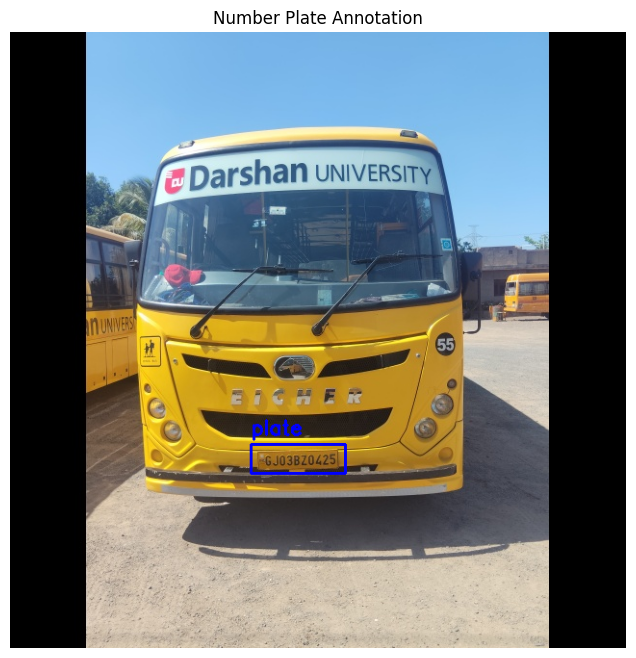

In [21]:
sample_image = train_images[0]

image = cv2.imread(str(sample_image))

if image is None:
    raise ValueError("Image could not be read.")

h, w = image.shape[:2]

label_file = (
    DATASET_DIR
    / "labels"
    / "train"
    / f"{sample_image.stem}.txt"
)

with open(label_file, "r") as f:
    lines = f.readlines()

for line in lines:

    parts = line.strip().split()

    class_id = int(parts[0])
    x_center = float(parts[1])
    y_center = float(parts[2])
    box_width = float(parts[3])
    box_height = float(parts[4])

    x1 = int((x_center - box_width / 2) * w)
    y1 = int((y_center - box_height / 2) * h)

    x2 = int((x_center + box_width / 2) * w)
    y2 = int((y_center + box_height / 2) * h)

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    cv2.putText(
        image,
        "plate",
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Number Plate Annotation")
plt.show()

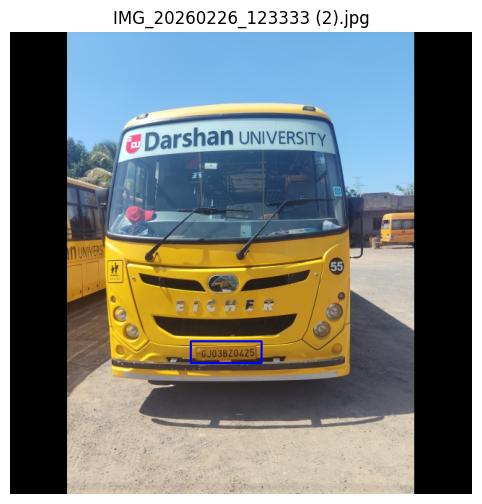

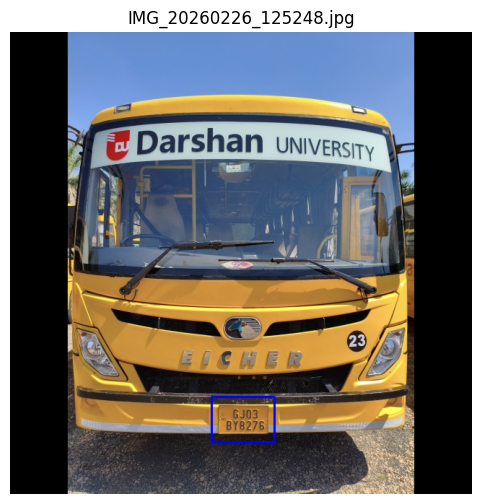

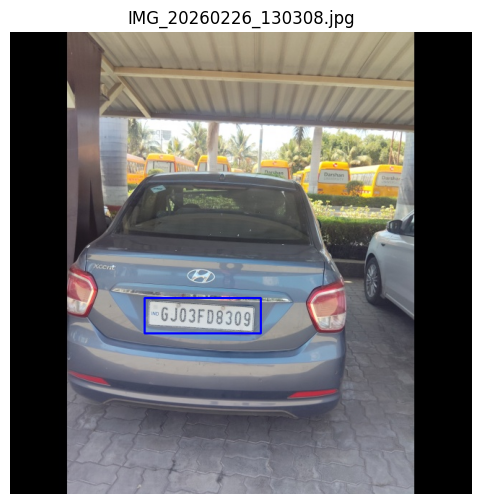

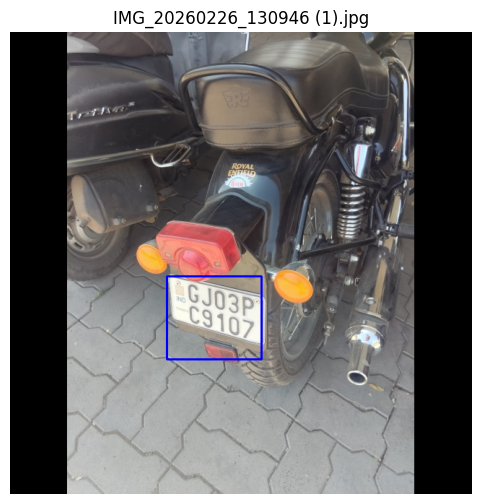

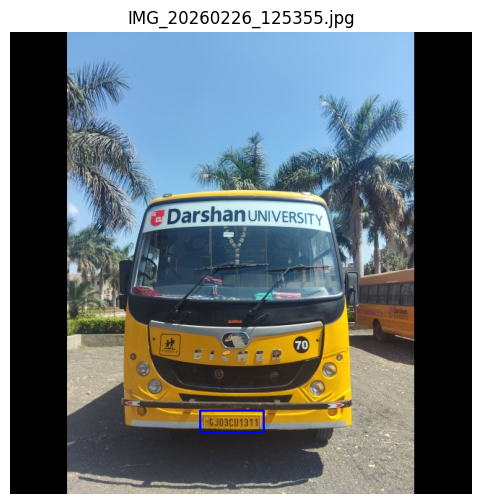

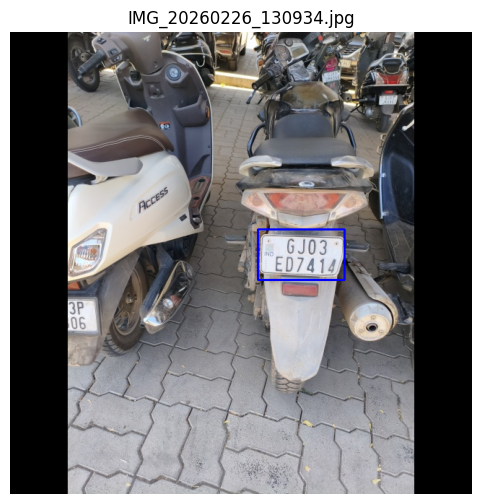

In [22]:
sample_images = random.sample(
    train_images,
    min(6, len(train_images))
)

for image_path in sample_images:

    image = cv2.imread(str(image_path))

    h, w = image.shape[:2]

    label_path = (
        DATASET_DIR
        / "labels"
        / "train"
        / f"{image_path.stem}.txt"
    )

    if not label_path.exists():
        continue

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:

        parts = line.strip().split()

        x_center = float(parts[1])
        y_center = float(parts[2])
        box_width = float(parts[3])
        box_height = float(parts[4])

        x1 = int((x_center - box_width / 2) * w)
        y1 = int((y_center - box_height / 2) * h)

        x2 = int((x_center + box_width / 2) * w)
        y2 = int((y_center + box_height / 2) * h)

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(image_path.name)
    plt.show()

In [23]:
MODEL_PATH = PROJECT_DIR / "yolo26n.pt"

plate_model = YOLO(str(MODEL_PATH))

print("YOLO26n pretrained model loaded successfully.")

YOLO26n pretrained model loaded successfully.


In [24]:
baseline_results = plate_model.predict(
    source=str(val_images[0]),
    conf=0.25,
    device="cpu",
    save=False
)

print("Baseline prediction completed.")


image 1/1 C:\Users\lenovo\downloads\ANPR_Traffic_AI\number_plate_detection\Gujarat_Vehicle_Dataset\images\val\IMG_20260226_123415.jpg: 640x640 2 buss, 649.6ms
Speed: 22.6ms preprocess, 649.6ms inference, 9.2ms postprocess per image at shape (1, 3, 640, 640)
Baseline prediction completed.


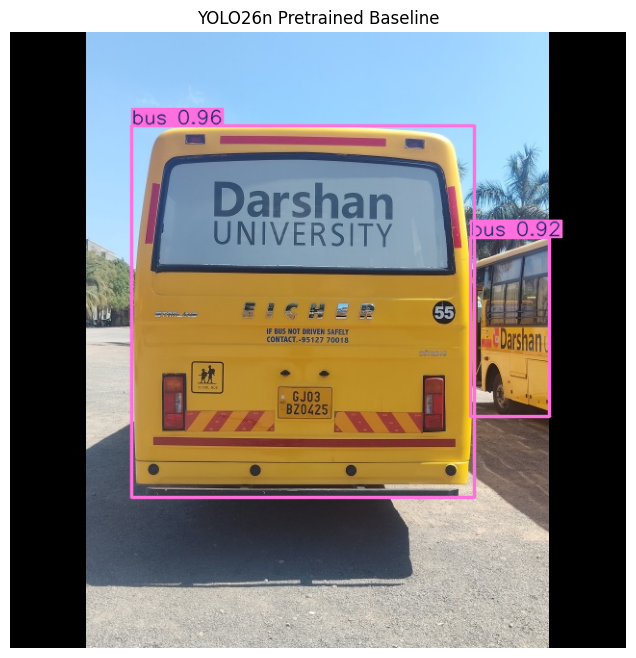

In [26]:
result = baseline_results[0]

annotated = result.plot()

plt.figure(figsize=(12, 8))

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.title("YOLO26n Pretrained Baseline")

plt.show()

In [28]:
# Create a clean YOLO configuration using absolute paths

PLATE_YAML = PROJECT_DIR / "number_plate_detection" / "plate_data.yaml"

plate_data = {
    "path": str(DATASET_DIR.resolve()),
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "plate"
    }
}

with open(PLATE_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(plate_data, f, sort_keys=False)

print("Created:", PLATE_YAML)
print()
print(PLATE_YAML.read_text(encoding="utf-8"))

Created: C:\Users\lenovo\downloads\ANPR_Traffic_AI\number_plate_detection\plate_data.yaml

path: C:\Users\lenovo\Downloads\ANPR_Traffic_AI\number_plate_detection\Gujarat_Vehicle_Dataset
train: images/train
val: images/val
names:
  0: plate



In [29]:
print("========== TRAINING DATA CHECK ==========")

print("Train folder exists:",
      (DATASET_DIR / "images" / "train").exists())

print("Val folder exists:",
      (DATASET_DIR / "images" / "val").exists())

print("Train images:", len(train_images))
print("Val images:", len(val_images))

print("YAML exists:", PLATE_YAML.exists())

========== TRAINING DATA CHECK ==========
Train folder exists: True
Val folder exists: True
Train images: 284
Val images: 71
YAML exists: True


In [30]:
MODEL_PATH = PROJECT_DIR / "yolo26n.pt"

plate_model = YOLO(str(MODEL_PATH))

print("YOLO26n pretrained model loaded successfully.")

YOLO26n pretrained model loaded successfully.


In [31]:
plate_train_results = plate_model.train(
    data=str(PLATE_YAML),
    epochs=10,
    imgsz=416,
    batch=4,
    patience=5,
    device="cpu",
    workers=0,
    project=str(PROJECT_DIR / "runs"),
    name="number_plate_detection_cpu10",
    exist_ok=True
)

print("Number plate detection training completed.")

Ultralytics 8.4.132  Python-3.13.9 torch-2.13.0+cpu CPU (AMD Ryzen 5 3500U with Radeon Vega Mobile Gfx)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\lenovo\downloads\ANPR_Traffic_AI\number_plate_detection\plate_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\lenovo\downlo

In [32]:
PLATE_RUN_DIR = (
    PROJECT_DIR
    / "runs"
    / "number_plate_detection_cpu10"
)

PLATE_BEST_MODEL = (
    PLATE_RUN_DIR
    / "weights"
    / "best.pt"
)

PLATE_LAST_MODEL = (
    PLATE_RUN_DIR
    / "weights"
    / "last.pt"
)

print("Best model exists:", PLATE_BEST_MODEL.exists())
print("Last model exists:", PLATE_LAST_MODEL.exists())

Best model exists: True
Last model exists: True


In [33]:
best_plate_model = YOLO(
    str(PLATE_BEST_MODEL)
)

print("Fine-tuned number plate detector loaded.")

Fine-tuned number plate detector loaded.


In [34]:
plate_metrics = best_plate_model.val(
    data=str(PLATE_YAML),
    imgsz=416,
    batch=4,
    device="cpu",
    workers=0
)

print("Validation completed.")

Ultralytics 8.4.132  Python-3.13.9 torch-2.13.0+cpu CPU (AMD Ryzen 5 3500U with Radeon Vega Mobile Gfx)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 112.940.0 MB/s, size: 128.6 KB)
val: Scanning C:\Users\lenovo\Downloads\ANPR_Traffic_AI\number_plate_detection\Gujarat_Vehicle_Dataset\labels\val.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 13.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.9it/s 6.3s0.3s
                   all         71         73      0.837      0.918      0.936      0.615
Speed: 1.2ms preprocess, 72.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\lenovo\Downloads\ANPR_Traffic_AI\runs\detect\val-2
Validation completed.


In [35]:
print("==========================================")
print("     NUMBER PLATE DETECTION RESULTS")
print("==========================================")

print(f"mAP50:     {plate_metrics.box.map50:.4f}")
print(f"mAP50-95:  {plate_metrics.box.map:.4f}")
print(f"Precision: {plate_metrics.box.mp:.4f}")
print(f"Recall:    {plate_metrics.box.mr:.4f}")

print("==========================================")

     NUMBER PLATE DETECTION RESULTS
mAP50:     0.9362
mAP50-95:  0.6153
Precision: 0.8369
Recall:    0.9178


In [36]:
test_image = val_images[0]

test_results = best_plate_model.predict(
    source=str(test_image),
    conf=0.25,
    device="cpu",
    save=False
)

print("Test prediction completed.")


image 1/1 C:\Users\lenovo\downloads\ANPR_Traffic_AI\number_plate_detection\Gujarat_Vehicle_Dataset\images\val\IMG_20260226_123415.jpg: 416x416 1 plate, 202.7ms
Speed: 5.2ms preprocess, 202.7ms inference, 2.9ms postprocess per image at shape (1, 3, 416, 416)
Test prediction completed.


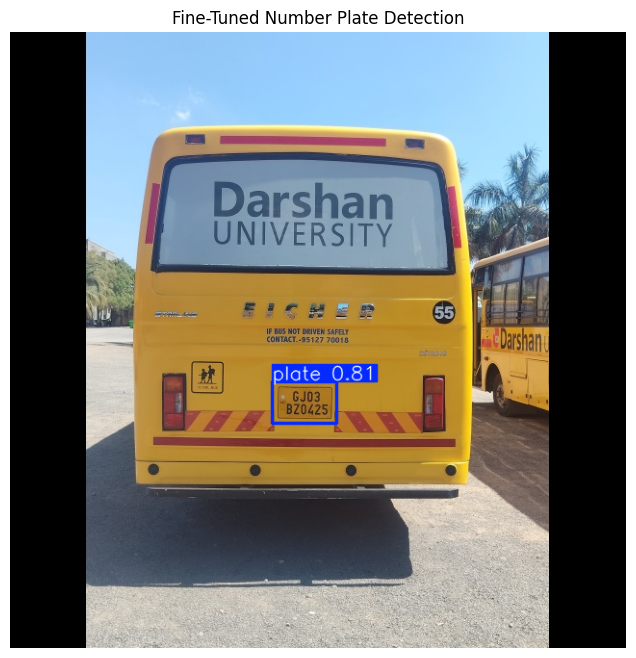

In [37]:
result = test_results[0]

annotated = result.plot()

plt.figure(figsize=(12, 8))

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.title("Fine-Tuned Number Plate Detection")

plt.show()

In [38]:
sample_test_images = random.sample(
    val_images,
    min(10, len(val_images))
)

multi_results = best_plate_model.predict(
    source=[str(p) for p in sample_test_images],
    conf=0.25,
    device="cpu",
    save=True
)

print("Predictions completed:", len(multi_results))


0: 416x416 2 plates, 65.0ms
1: 416x416 2 plates, 65.0ms
2: 416x416 2 plates, 65.0ms
3: 416x416 (no detections), 65.0ms
4: 416x416 1 plate, 65.0ms
5: 416x416 1 plate, 65.0ms
6: 416x416 1 plate, 65.0ms
7: 416x416 1 plate, 65.0ms
8: 416x416 1 plate, 65.0ms
9: 416x416 1 plate, 65.0ms
Speed: 2.4ms preprocess, 65.0ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\lenovo\Downloads\ANPR_Traffic_AI\runs\detect\predict-2
Predictions completed: 10


In [39]:
FINAL_MODEL_DIR = PROJECT_DIR / "models"
FINAL_MODEL_DIR.mkdir(exist_ok=True)

FINAL_PLATE_MODEL_PATH = (
    FINAL_MODEL_DIR /
    "number_plate_detection_best.pt"
)

shutil.copy2(
    PLATE_BEST_MODEL,
    FINAL_PLATE_MODEL_PATH
)

print("Final model saved at:")
print(FINAL_PLATE_MODEL_PATH)

Final model saved at:
C:\Users\lenovo\downloads\ANPR_Traffic_AI\models\number_plate_detection_best.pt


In [40]:
print("=" * 60)
print("       NUMBER PLATE DETECTION - FINAL SUMMARY")
print("=" * 60)

print("Model: YOLO26n")
print("Dataset: Gujarat_Vehicle_Dataset")

print("\nImages:")
print("Training:", len(train_images))
print("Validation:", len(val_images))

print("\nClass:")
print("0 -> plate")

print("\nPerformance:")
print(f"mAP50:     {plate_metrics.box.map50:.4f}")
print(f"mAP50-95:  {plate_metrics.box.map:.4f}")
print(f"Precision: {plate_metrics.box.mp:.4f}")
print(f"Recall:    {plate_metrics.box.mr:.4f}")

print("\nFinal model:")
print(FINAL_PLATE_MODEL_PATH)

print("=" * 60)

       NUMBER PLATE DETECTION - FINAL SUMMARY
Model: YOLO26n
Dataset: Gujarat_Vehicle_Dataset

Images:
Training: 284
Validation: 71

Class:
0 -> plate

Performance:
mAP50:     0.9362
mAP50-95:  0.6153
Precision: 0.8369
Recall:    0.9178

Final model:
C:\Users\lenovo\downloads\ANPR_Traffic_AI\models\number_plate_detection_best.pt
